# MTH5001:  Introduction to Computer Programming 2020/21

## Final Report Project: "Deconstructing SARS-CoV-2"


<div class="alert alert-block alert-danger">

**IMPORTANT**: 
Start by filling in your Name and student ID below. **DO IT NOW**. Save this Jupyter Notebook with the name *MTH5001_surname_ID.ipynb*, where instead of *surname* and *ID* you write your surname and your student ID number.
Use the available cells to introduce the code. You can add additional cells if needed. explain your code as much as possible with `# comments` </div>

<div class="alert alert-block alert-warning">
    
### Name: Hadeel Elsawy Ali

### ID: 190349325




<br />







---
### Some context
This project is an investigation on the genetic structure of SARS-CoV-2, the coronavirus that is causing the COVID-19 pandemic (or, at least, the original variant as it emerged in Wuhan). In particular, we are going to analyse in some detail a so-called DNA nucleotide sequence.

So what is this?
DNA stands for desoxyribonucleic acid. SARS-CoV-2 coronavirus is what is called a RNA (ribonucleic acid) virus, meaning that the genetic material of the virus is essentially simply a single strand of RNA, i.e. a long RNA chain.
Both DNA and RNA are assembled as a chain of 'nucleotides', organic molecules which usually are symbolized as letters:
Adenine ('A'), Cytosine ('C'), Guanine ('G'), Thymine ('T') (in RNA Uracil 'U' is found instead of Thymine).
A sequence of nucleotides is therefore a sequence of letters, for instance CATCGATCAGTAGAGTTTAC...
In a nutshell, the genetic material of the virus can be described as a long sequence of these four letters.

The story is more intricate, and by no means this is a project on computational virology. We are nonetheless borrowing all this for inspiration. The starting point of the project is to consider a DNA sequence. For those of you that don't have any interest in genetics, you can simply assume that the starting point is to consider a very long sequence of letters, where each letter is extracted from an alphabet of four letters (A,C,G,T).

This project consists in four parts. In each of the parts you will need to code up some specific functions, run some code, and respond to some questions. Recall that all code needs to be properly documented with `# comments`, and the explanations in these comments will indeed be assessed and you will receive lots of marks for adequate documentation. 



* The **first part** is about loading data. This data is just a file that depicts a very long 4-letter sequence of DNA nucleotides, something like ATATCGTAGCTAT... 
This letter sequence characterises the virus genetic material. From now on we will call this the *virus sequence*.

* The **second part** is about some basic manipulation and visualisation of the virus sequence.

* The **third part** is about computing some statistics of this sequence and do some additional visualisation.


<br />

Reference: [Wu, F., Zhao, S., Yu, B. et al. A new coronavirus associated with human respiratory disease in China. Nature **579**, 265–269 (2020).](https://doi.org/10.1038/s41586-020-2008-3)

---

The following code box is used to load any necessary modules. **You may not import any other modules.**

In [2]:
#DO NOT CHANGE THE CONTENT OF THIS CODE BOX
import matplotlib.pyplot as plt
import seaborn
import numpy as np
import scipy.linalg as la
import random

# Part 1: Loading data 
*** ***

<div class="alert alert-block alert-danger">
    
Please remember to write plenty of `# comments` in the code cells. Mark scheme is depicted in each question. 50% of the marks will go to assess the actual code, and 50% of the marks will go to assess the `# comments`.


---
Load the virus' genome DNA code (the virus sequence). For this,

**[1.1]** Define a function that takes a string and converts it into a list of characters, such that the string 'hello' is converted into ['h','e','l','l','o']



---

In [3]:
#The following function takes a string and converts it into a list of character strings using the inbuilt functon list().
def characters(string): #Defines the function characters, it takes a string input.
    return list(string) #The function returns a list of the string input, where each letter is its own string.
print(characters('Hello'))#Testing the function works using the string 'Hello'.

['H', 'e', 'l', 'l', 'o']


---
**[1.2]** Subsequently, open the file *sequence.txt* (you should download this file from qmplus and store it in the same folder of your Jupyter Notebook). Read and load the data of the file in a string variable called *str1*. Remove any newline characters from *str1*, and, using the code of question [1.1], store the resulting string in a list of characters called *str2*. As a result, the elements of *str2* should be the letters of the sequence. From now on we will refer to *str2* as the virus sequence.

---

In [4]:
with open("sequence.txt","r") as f: #Opens the file sequence.txt to read the contents. The file can be referred to as f.
    #Using "with" is convinient. It guarantees that the file is closed after implementing the code.Changes made to a file 
    #will not be implemented until after the file is closed.
    
    str1=f.read() #The data is loaded in the string variable str1.
    str2=characters(str1.replace('\n', '')) #(*)
    #print(str2) #Testing if a list of strings (of each base) is produced.
    
#(*) Str2 takes str1 and replaces the newline characters, '/n' with ''  then passes the string through the function Characters
#where each base is printed as a string in a list.



## # Part 2: Visualising the genome 
*** ***

<div class="alert alert-block alert-danger">
    
Please remember to write plenty of `# comments` in the code cells. Mark scheme is depicted in each question. 50% of the marks will go to assess the actual code, and 50% of the marks will go to assess the `# comments`.




---
**[2.1]** Define a Python function called $mapping$(x) that, given a letter-list $x_L$, generates a number-list $x_N$ by mapping each of the 4 letters into a different number. Specifically, implement the changes
$$A \mapsto -2; \ C \mapsto -1; \ G \mapsto 1; \ T \mapsto 2\;.$$
(For example, $x_L=[A,T,T,A,C,G]$ is mapped into $x_N=[-2,2,2,-2,-1,1]$.) You may assume that there are no other occurring letters.

---


In [5]:
def mapping(x):#Defines the function mapping which takes a list of strings as an input. 
    bases={'A':-2,'C':-1,'G':1,'T':2} #Defining my dictionary. The bases strings are the keys and the numbers they are 
    #mapped to are the value of eacy base.
    return ([bases[x] for x in x]) #Returns the number associated with the letter present in the list of strings, x.

mapping(['A','T','T','A','C','G','A'])#Testing this function works.

#The input can only contain the bases A, C, G and T, otherwise there will be an error (no other letters have been included 
#in the dictionary). Also, the bases must each be in their own string (as shown in the keys of the dictionary),
#otherwise an error will occur.Examples are shown below.
#mapping(['A','T','T','A','Y','G','A']) Produces an error since Y is not defined
#mapping(['ACTT']) Produces as error since 'ACTT' is not included in the bases dictionary. 

#Sources:
#https://stackoverflow.com/questions/63895564/using-a-list-of-dictionaries-to-associate-letters-with-numbers-in-python

[-2, 2, 2, -2, -1, 1, -2]

---
**[2.2]** Implement a function called $walker$(x) that, given a list $x$ of N numbers [x(0), x(1), x(2),...,x(N-1)], outputs a "walk list" $y=[y(0), y(1), ..., y(N)]$, defined recursively as: 
$$y(0) = 0,\\
y(n) = y(n-1) + x(n-1), \ \text{if} \ 0<n\leq N$$

---


In [6]:
def walker(x):#Defines the function walker, which takes a list of integers,x, as an input.
    
    y=[0] #'y' is the list containing only the element 0. This is where the function will store each y value that is computed.
    y_n=0 #The first y value,y0 is 0. To be used when computing each y value when iterating.
    for x_n in x: #This for loop computes y values for each element of the list,x.
        y_n+=x_n #Sums each precceding term xn-1 and yn-1 to give the next y term,yn.
        y.append(y_n)#Stores the next y value in the list y.

    return y #This returns the walk list y for each input list,x.

print(walker([-2,1,2,-1,1]))#Testing if the function works.

#Sources:
#https://stackoverflow.com/questions/55786911/iterating-through-a-list-using-recursion
#https://stackoverflow.com/questions/35125129/append-to-list-while-in-recursive-loop

[0, -2, -1, 1, 0, 1]


---

**[2.3]** Given points $(x_i,y_i)$ in the plane, a least-squares fit to a line $y=a x + b$ gives formulas for the slope $a$ and the intercept $y=b$ as
$$a=\frac{\langle x_iy_i\rangle-\langle x_i\rangle\langle y_i\rangle}{\langle x_i^2\rangle-\langle x_i\rangle^2}\quad\text{and}\quad b=\langle y_i\rangle-a\langle x_i\rangle\;,$$
where $\langle r_i\rangle$ denotes the average of the numbers $r_i$.

Without using any imported module, define a function called *linear_fit()* that:
* takes a (finite) list of points $z=[(x_0,y_0),(x_1,y_1),(x_2,y_2),...]$ as an input,
* fits a straight line to $y=a x + b$ by performing a least-squares fit,
* returns the values of $a$ and $b$.

Use
```python
def linear_fit_test(z):
    a,b=np.polyfit(*zip(*z), 1)
    return a,b
```

to compare the output of both functions for some well-chosen list of points to ensure that your function works appropriately.

---


In [7]:

def linear_fit(z):#Defines the function linear_fit, which takes a list of tuples as an input.
    prodxy=0 #This initializes the first value of the product of x and y (before being iterated in for loop), which is 0.
    sumx=0 #Initializes the first value of the sum of x, 0.
    sumy=0 #Initializes the first value of the sum  y, 0.
    sumxx=0 #Initializes the first value of the sum of x squared, 0.
    
    for tup in z: #I used a for loop to efficiently compute all averages before computing a and b.
    #Considers each tuple in z. This is necessary to find the sums, products and averages.
       
        #Average of products of xis and yis
        prodxy= prodxy + tup[0]*tup[1] 
        avxy=prodxy/len(z)

#This iterates the products of x and y for each tuple in z, the list of tuples.
#It takes our inital value of the product, which it 0, then adds the products of x and y (where x is denoted as tup[0] and y 
#is tup[1]).
#The product of x and y for our first tuple is then stored as prodxy.This process is repeated for each tuple.
#The product of x and y is then divided by the number of tuples (which is len(z)) and is stored as avxy (the average of 
#the product of x and y).
        
        #Average of x
        sumx=sumx+tup[0]
        avx=sumx/len(z)

#Computes the average of x in each tuple of the list z.
#x is denoted as tup[0] since it is the first element of each tuple of z
#It takes our inital value of the sum of x, which it 0, then adds x of the first tuple. 
#The sum of x for our first tuple is then stored as sumx.This process is repeated for each tuple.
#The sum of x is then divided by the number of tuples (which is len(z)) and is stored as avx (the average of x).
        
       #Average of y
        sumy=sumy+tup[1]
        avy=sumy/len(z)
        
#The average of y in computed above.
#y is denoted as tup[1] since it is the second element of the tuples in z
#The equation takes our inital value of the sum of y, which it 0, then adds y of the first tuple.
#The sum of y for our first tuple is then stored as sumx.This process is repeated for all tuples.
#The sum of y is then divided by the number of tuples (which is len(z)) and is stored as avy (the average of y).

        #Average of (xi squared)
        sumxx=sumxx+(tup[0]**2)
        avxx=sumxx/len(z)
        
#The average of xi squared is computed above. 
#The equation takes our inital value of the sum of x squared, which it 0, then adds x squared of the first tuple.
#The sum of x squared for our first tuple is then stored as sumxx.This process is repeated for all tuples.
#The sum of x squared is then divided by the number of tuples (which is len(z)) and is stored as avxx (the average of x 
#squared).
        
    a=(avxy-(avx*avy))/((avxx)-(avx)**2)
    b=avy-a*avx

#The equations of a and b is shown above using the avx,avy,avxx and avxy we defined above. 

    return a,b #Outputs the tuple (a,b) when given a list of tuples as an input.




def linear_fit_test(z):
    a,b=np.polyfit(*zip(*z), 1)
    return a,b

#Testing if the function works by comparing values with linear_fit_test
print(linear_fit([(1,2),(6,3),(2,3),(7,12)]))
print(linear_fit_test([(1,2),(6,3),(2,3),(7,12)]))

#Sources:
#https://stackoverflow.com/questions/10048571/python-finding-a-trend-in-a-set-of-numbers

(1.1538461538461537, 0.384615384615385)
,(1.1538461538461542, 0.3846153846153809)


---
**[2.4]** Using the function *linear_fit()* or otherwise, define a function called *linear_trend()* that:
* takes a list of numbers $z=[z_0,z_1,z_2,...]$ as an input;
* fits a straight line to $y=\alpha x + \beta $ to the data of the form $(p,z_p)$;
* finally returns a list of the same size as $z$, such that the p-th element of that list displays $\alpha p + \beta$.

---


In [8]:
def linear_trend(z): #Defines the linear_trend function, which takes a list of integers as an input.
    
    coord=[(p,z[p]) for p in range(len(z))]
    #Assigns the list of coordinates (p,zp) to the word coord. The coordinates are iterated for each integer between 0
    #and len(z). I could have also used the inbuilt zip function if i had defined the list of p first.It is necessary 
    #to produce the list of coordinates as I plan to use the linear fit function which can only take list of coordinates
    #(list of tuples) as an input.
    
    #Gradient and intercept of the least squares fit of the line passing through the coordinates:
    a=linear_fit(coord)[0] #The coordinates are substituted into the linear_fit function.This is the value of the gradient.
    b=linear_fit(coord)[1]#This is the y intercept.
    
    z_p=[a*p+b for p in range(len(z))]#For the range(len(z)), p is taken into ap+b to produce a list of all the zp values.
    return z_p #Returns the list of zp values, which are the y values for the straight line fitted to the data.

print(linear_trend([3,4,6,9]))#Testing the function works.

[2.5, 4.5, 6.5, 8.5]


---
**[2.5]** Plot a graph that shows the list *virus_walk = walker(mapping(str2))*, along with the best straight line fit obtained from *linear_trend(walker(mapping(str2)))*, where *str2* is a list that contains the virus sequence. 

The detrended virus walk removes the linear trend (detrends) from the virus walk. Its generic p-th element is   
$$\text{detrended_virus_walk}[p] = \text{virus_walk}[p] - (a p + b) $$

In a second plot, show the detrended virus walk.

---

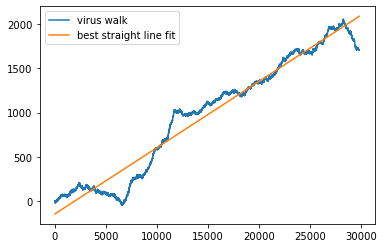

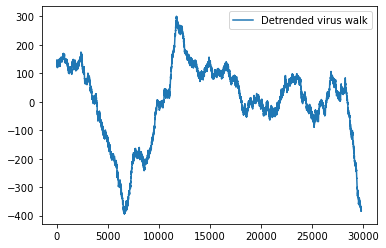

In [9]:
#FIRST PLOT
virus_walk=walker(mapping(str2))#Assigns walker(mapping(str2)) to the variable virus_walk.Virus walk is a list of integers.
linear_virus=linear_trend(virus_walk)#Assigns linear_trend(virus_walk) to the variable linear_virus. 'linea_virus' is a
#list of integers.

plot1=plt.figure(1)#Produces the first figure.
plt.plot(virus_walk, label="virus walk") #Plots the virus walk as y, using the index as x.
plt.plot(linear_virus,label='best straight line fit')#Plots linear_virus as y, using the index as x. This is plotted on the 
#same graph as virus_walk. Each plot is labelled.
plt.legend()#Displays the legend of the first plot.


#SECOND PLOT
linear=linear_trend(virus_walk)#Fits a straight line to the virus walk data and returns ap+b
detrended_virus_walk=[] #Empty list to store the values in detrended_virus_walk.

for num1,num2 in zip(linear,virus_walk):#Iterates for each coordinate.
    detrended_virus_walk.append(num2-num1)#This puts each value computed from the diffrence virus_walk-ap_b into our
    #empty list detrended_virus_walk.

plot2=plt.figure(2)#Produces the second figure.
plt.plot(detrended_virus_walk,label='Detrended virus walk')#Plots detrended_virus_walk with x as the index of each element 
#in the list, with a label.


plt.legend()#Shows the legend on the graph.
plt.show()#Displays figures.

---
**[2.6]** A simple random walk is defined as a walk list $y=[y(0), y(1), ..., y(N)]$, defined recursively as: 
$$y(0) = 0,\\
y(n) = y(n-1) + x(n-1), \ \text{if} \ 0<n\leq N$$ where for each n the steps *x(n)* are random values extracted from some set. 

Generate **five** simple random walks of length equal to *walker(mapping(str2))* with steps generated at random from the set $\{-2,2\}$. You may wish to generate random steps using the function *random.choice()*.

Show, in a plot, the detrended walk *detrended_virus_walk*, together with these five simple random walks.

Compare the detrended walk with the simple random walks. What do you notice? If you can, formulate a conjecture based on your observations.

---

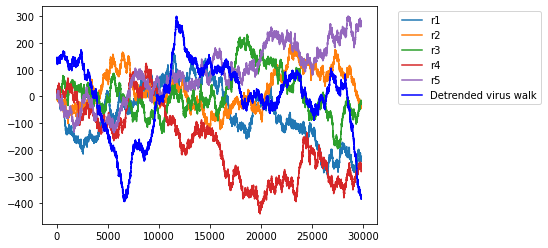

In [18]:
n=len(virus_walk) #Assigns the length of virus walk to n for conciseness.
x1=[random.choice([-2,2]) for i in range(n+1)]#Produces a list of n randomly chosen steps from the set [-2,2].
x2=[random.choice([-2,2]) for i in range(n+1)]#Produces a list of n randomly chosen steps from the set [-2,2].
x3=[random.choice([-2,2]) for i in range(n+1)]#Produces a list of n randomly chosen steps from the set [-2,2].
x4=[random.choice([-2,2]) for i in range(n+1)]#Produces a list of n randomly chosen steps from the set [-2,2].
x5=[random.choice([-2,2]) for i in range(n+1)]#Produces a list of n randomly chosen steps from the set [-2,2].
    
r1=walker(x1)#The list x1 is inputted into walker function then assigned to the variable r1, the first random walk.
r2=walker(x2)#The list x2 is inputted into walker function then assigned to the variable r2, the second random walk.
r3=walker(x3)#The list x3 is inputted into walker function then assigned to the variable r3, the third random walk.
r4=walker(x4)#The list x4 is inputted into walker function then assigned to the variable r4, the fourth random walk.
r5=walker(x5)#The list x5 is inputted into walker function then assigned to the variable r5, the fifth random walk.

plt.plot(r1,label='r1')#r1 is plotted as y with the index of each element of r1 as the x value in the plot.
plt.plot(r2,label='r2')#r2 is plotted as y with the index of each element of r2 as the x value in the plot.
plt.plot(r3,label='r3')#r3 is plotted as y with the index of each element of r3 as the x value in the plot.
plt.plot(r4,label='r4')#r4 is plotted as y with the index of each element of r4 as the x value in the plot.
plt.plot(r5,label='r5')#r5 is plotted as y with the index of each element of r5 as the x value in the plot.
plt.plot(detrended_virus_walk,label='Detrended virus walk', color='blue') #detrended_virus_walk is plotted as y and the index
#are taken as the x coordinates in the plot.
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')#Prints the legend outside the graph on the top left.
plt.show()#Displays all figures.


The five random walks, r1 to r5, follow the same trend as the detrended virus walk where they change incrementally, therefore they can be used to model the occurrence of A,G and C, T in the virus sequence. This is an example of the use of Markov Chains to model real world phenomena.

# Part 3 -- Statistical analysis of the genome
*** ***
<div class="alert alert-block alert-danger">
    
Please remember to write plenty of `# comments` in the code cells. Mark scheme is depicted in each question. 50% of the marks will go to assess the actual code, and 50% of the marks will go to assess the `# comments`.


---
**[3.1]** Define a function called *freq()* that computes the histogram of a virus sequence list. 
For this function, you cannot use any function defined in any module. 

Use the function *freq()* to plot a frequency histogram (bargraph plot) of the virus sequence, where the frequency of each nucleotide should appear as a blue bar, and the x axis should depict the four nucleotides A,C,G and T from left to right in alphabetical order.

---

{'A': 4, 'C': 0, 'G': 2, 'T': 1}


Text(0.5, 1.0, 'Frequency of bases in virus sequence')

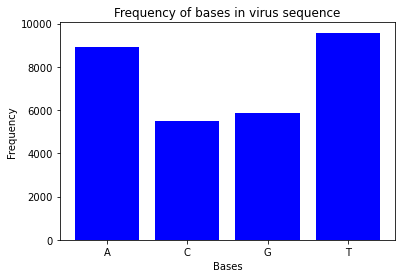

In [19]:
def freq(z):#Defines the function freq, which takes a list of strings (of bases) as an input.
    frequency1={} #Empty dictionary to compute the frequency.
    bases1=['A','C','G','T']#The elements that are counted.This will be used to iterate through.
    for i in bases1: #Iterates through the bases1 list. An output is given for each element of the bases1 list.
    
        frequency1[i]=z.count(i) #Counts the amount of each base is present in the list of strings. This is done
        #in the order given in bases1 which means that the frequencies will be computed in alphabetical order. 
        #Hence this method doesn't require finding a way to move the bars of the bargraph (later on in the question).
    
    return frequency1 #Returns the dictionary frequency1 which now has the bases as keys and frequency of each
    #base as the values.   

print(freq(['A','G','T','A','A','A','G']))#Testing if the function works to compute frequency of bases.

bases=freq(str2).keys()#Assigns the keys of the outputted dictionary (of freq(str2)) to the the variable 'bases'(to be plotted).
freq1=freq(str2).values()#Assigns the values of the outputted dictionary (of freq(str2)) to the variable 'freq1'(to be plotted).
plt.bar(bases,freq1,color="blue")#Plots a bar graph with bases on the x axis and freq1 on the y axis. The bars are colored blue.
plt.ylabel('Frequency')#Labels the y axis as 'Frequency'.
plt.xlabel('Bases')#Labels the x axis as 'Bases'.
plt.title('Frequency of bases in virus sequence')#Labels the the graph as 'frequency of bases in virus sequence'.

#Sources:
#https://stackoverflow.com/questions/35125129/append-to-list-while-in-recursive-loop
#https://stackoverflow.com/questions/40985203/counting-letter-frequency-in-a-string-python

---
**[3.2]** A so-called *2-gram* is defined as a block of two consecutive letters. For instance, in the sequence AACTGC we can find five different 2-grams: AA, AC, CT, TG and GC (notice that two consecutive 2-grams overlap in one letter). It is easy to see that in a sequence of $N$ letters, we can count $N-1$ 2-grams (many of them may be repeated, so the total number of *different* 2-grams is possibly smaller).

For sequences composed by letters whose alphabet is of size 4 (like the virus RNA, whose alphabet is made by four letters A,C,G and T), there are a total of $2^4=16$ possible 2-grams: AA,AC,AG,AT,...,TT.

By modifying the function *freq()* (or otherwise), compute and plot a histogram (bar graph plot) of the frequency of 2-grams in the virus sequence. The x axis should depict all sixteen combinations of the four nucleotides.

---

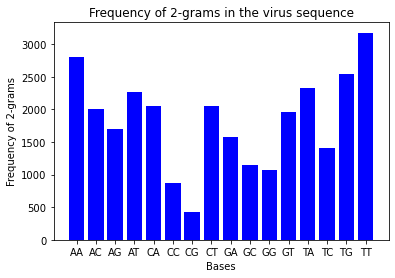

In [20]:
#I will be using str1 in this code rather than str2.(since it is more 
#efficient than using my code for concatenating str2 below).

#Function to concatenate the virus sequence
def concat(z): #Defines the function 'concat', which takes a list of strings as an input.
    concatlist=[]#An empty list to store the concatenated string of bases.
    for item in z:#Iterates for each base string in z. An output is given for each element of z (each base).
        concatlist.append(item) #This changes the empty list, concatlist, to a list of bases by adding each base to the list.
        result = ''.join(concatlist)#Converts the list of bases into a sting.
    return result #Outputs the concatenated string of all the bases. 

#Counts multiple occurences of substring in string
def CountOverlaps(string, substring):#Defines the function 'CountOverlaps' which takes a string and substring
    #as an input.
    count = 0 #Initializes the first value of the count, 0.
    first = 0 #Initializes the first value of first, 0.
    while first < len(string): #Looks through the length of the string input.
        position = string.find(substring, first)#position is the index of the first occurrence of the substring within the string.
        if position != -1:#On the condition that the substring is present, 
            first = position + 1 #First is moved to the beginning of substring.
            count += 1#The count is increased by 1.
        else:
            # On the condition that there are no more substrings, the iteration is broken.
            break
    return count #The frequency of the substring in the string,'count', is returned.

def freq_2gram(string):#Defines the function 'freq_2gram', that takes a list of bases as an input.
    frequency=[]#Empty list to store the frequencies.
    bases=['AA','AC','AG','AT','CA','CC','CG','CT','GA','GC','GG','GT','TA','TC','TG','TT']#The list of bases that the code 
    #will count the frequencies of.
    
    for i in bases:#Iterates for each type of 2-gram. 
        count=CountOverlaps(string,i)#Inputs the string into the CountOverlaps function, and the first 2-gram 
        #from the bases list.
        frequency.append(count)#The count is stored in the empty list frequency. This is repeated for each 2-gram in 'bases'.
    return frequency#Outputs the occurences of each 2-gram in alphabetical order, as a list of integers.

x=['AA','AC','AG','AT','CA','CC','CG','CT','GA','GC','GG','GT','TA','TC','TG','TT']  #Defines x to be the bases (for our bar 
#graph).
y=[CountOverlaps(str1,i) for i in x]
#y=freq_2gram(concat(str2)) #Defines y to be the frequency of each base, in the order of the 2-grams in x.

plt.bar(x,y,color="blue") #Plots the histogram in the colour blue.
plt.ylabel('Frequency of 2-grams') #Labels the y axis as 'Frequency of 2-grams'.
plt.xlabel('Bases') #Labels the x axis as Bases.
plt.title('Frequency of 2-grams in the virus sequence')#Title of the histogram, 'Frequency of 2-grams in the virus sequence'.
plt.show()#Displays the figure.

#Sources:
#https://www.knowledgehut.com/blog/programming/concatenate-strings-python
#https://www.geeksforgeeks.org/python-ways-to-concatenate-two-lists/
#https://www.geeksforgeeks.org/python-count-overlapping-substring-in-a-given-string/
#https://stackoverflow.com/questions/12453580/how-to-concatenate-items-in-a-list-to-a-single-string
#https://stackoverflow.com/questions/40985203/counting-letter-frequency-in-a-string-python
#https://stackoverflow.com/questions/12169839/which-is-the-preferred-way-to-concatenate-a-string-in-python
#https://likegeeks.com/seaborn-heatmap-tutorial/

In [21]:
#This was my inital code for finding the frequency of 2-grams in a concatenated string but i noticed that it 
#doesnt count overlapping 2-grams so I had to change it to CountOccurrence(sring,substring) and freq_2gram(string).

def freq2(z): #Function to find the frequency of 2-grams in virus sequence list.
    frequency2={} #Empty dictionary to compute the frequency.
    bases2=['AA','AC','AG','AT','CA','CC','CG','CT','GA','GC','GG','GT','TA','TC','TG','TT']#The elements that are counted.
    for i in bases2: #An output is given for each element of the bases list.
    
      frequency2[i]=z.count(i) #This counts the amount of each base (from the base list) are present in the virus sequence list
    
    return frequency2 #Returns the dictionary we have defined.   

---
**[3.3]** Let $N(ij)$ be the frequency (that is, the number of occurrences) of the 2-gram 'ij' in the virus sequence, for $i,j=A,C,G,T$.
The transition matrix ${\bf T}=\{T_{ij}\}$ of a given sequence is defined such that the general term $T_{ij} = N(ij)/N_{tot}(i),$
where $N_{tot}(i)$ is the frequency of letter 'i' showing up in the sequence. By construction, all rows of $\bf T$ should sum up one.

Compute the $4\times 4$ transition matrix $\bf T$ of the virus sequence. Print this matrix and display it as a heatmap of this matrix using *seaborn*.

Confirm that the largest eigenvalue of $\bf T$ is one, and give the associated eigenvector $v$. Check your results by computing ${\bf T}v$.

---

[[0.3194881  0.22698698 0.19499326 0.25853166]
, [0.37964989 0.16137856 0.08005106 0.3789205 ]
, [0.27473091 0.19921408 0.18657099 0.33948403]
, [0.24762402 0.14736292 0.26997389 0.33493473]]
,
,Largest eigenvalue is: 0.9999664641148356
,
,Associated eigenvectors are: [-0.50001666+0.j -0.50001076+0.j -0.5000123 +0.j -0.49996027+0.j] 
,
,
,Tv: [-0.49999989+0.j -0.49999399+0.j -0.49999553+0.j -0.49994351+0.j]
,
,
,AxesSubplot(0.125,0.125;0.62x0.755)


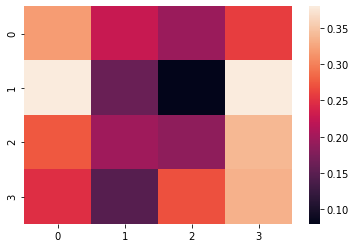

In [22]:
v=freq_2gram(concat(str2)) #Assigns freq_2gram(concat(str2)) to the variable v, for convinience.
u=list(freq(str2).values())#Assigns list(freq(str2).values()) to the variable u, for convinience.

#The rows of the n_ij matrix are below. Each 4 elements of v are assigned to a row in the n_ij matrix.
first_nij=[v[i] for i in range(4)] #The first row of n_ij matrix (the first 4 elements of v)
second_nij=[v[i] for i in range(4,8)]#The second row of n_ij matrix.
third_nij=[v[i] for i in range(8,12)]#The third row of n_ij matrix.
fourth_nij=[v[i] for i in range(12,16)]#The fourth row of n_ij matrix.

#The rows of n_i are computed below. Each element of u are taken as every element in the row (this is in order to
#compute element-wise division later on).

na=u[0]#The total frequency of the base A.
nc=u[1]#The total frequency of the base C.
ng=u[2]#The total frequency of the base G.
nt=u[3]#The total frequency of the base T.

#Forming the rows of n_i:
first_ni=list((na,na,na,na))#The first row of n_i matrix.
second_ni=list((nc,nc,nc,nc))#The second row of n_i matrix.
third_ni=list((ng,ng,ng,ng))#The third row of n_i matrix.
fourth_ni=list((nt,nt,nt,nt))#The fourth row of n_ij matrix.

#Producing the matrices n_ij and n_i:
n_ij=np.array([first_nij,second_nij,third_nij,fourth_nij])#Produces a matrix for n_ij using np.array.
n_i=np.array([first_ni,second_ni,third_ni,fourth_ni])#Produces a matrix for n_i using np.array.

#Producing the transition matrix,T:
T=n_ij/n_i #Computes element-wise division to find the transition matrix, T.

#Printing values:
print(T)#Prints transition matrix
print()
eval_T,evec_T=la.eig(T)#Assigning the eigenvalues to variables 'eval_T' and the eigenvectors to 'evec_T'for easy accessability.
print('Largest eigenvalue is:', np.real(eval_T[0]))#The first element of eval_T is the largest eigenvalue
print()
print('Associated eigenvectors are:', evec_T[:,0],'\n')#The first element of evec_T is the associated eigenvector.
print()
print('Tv:',T@evec_T[:,0])#Matrix multiplication of T and v,Tv.
print()
print()
print(seaborn.heatmap(T))#Produces a heatmap of the transition matrix.

#Sources:
#https://www.programiz.com/python-programming/examples/add-matrix)
#https://stackoverflow.com/questions/46657221/generating-markov-transition-matrix-in-python/46657489

---
**[3.4]** Define a function called $deviation(x)$. The input of the function is a walk list $x$. This function performs the following computation:
* It iteratively considers all possible sublists $x_k=[x(0), ..., x(k)]$, where $k=1,2,4,\ldots$ runs through powers of $2$.
* For each possible value of $k$, the function computes $\Delta(k) = max(x_k) - min(x_k)$. 
* The function $deviation$ finally returns a list of the form $[(k,\Delta(k))]$ for all possible values of $k$. 
* That final list is called the *scaling* (this is important for next questions below)

For the case $x=[0,1,2,3,4,5,6,7,8]$ you should get $[(1, 1), (2, 2), (4, 4), (8, 8)]$, whereas for the case $x=[1,1,1,1]$ you should get $[(1,0),(2,0)]$.

---

In [23]:
def deviation(x):#Defines the function deviation which takes a list of integers as an input.
    index=list(range(len(x)))#Produces the list of indexes of each element of x.
    k=[2**i for i in range(len(x)+1)]#The list of k values, powers of 2, for each index of x.
    delta=[]#Empty list to store the difference of the maximum x and minimum x of each sublist, xk, in x. 
    x_list=[]#[x[0:i+1] for i in k]#The list of sublists, xk, in x   
    
    for i in k:
        if i in index:
            x_list.append(x[0:i+1])
            
    for item in x_list:#For each sublist, xk, of x.
        delta.append(max(item)-min(item))#Stores the difference of the maximum and minimum of the sublists of x in delta.
        scaling=list(zip(k,delta))#Assigns the list of tuples (k,delta) in the variable scaling.
       
    return scaling #Returns scaling, the list of tuple (k,delta), when a list is inputted.



#Testing the function works with the examples in the question (it produes the same output):
x=[0,1,2,3,4,5,6,7,8]
y=[1,1,1,1]
print(deviation(x))
print(deviation(y))

#Sources:
#https://stackoverflow.com/questions/35125129/append-to-list-while-in-recursive-loop
#https://stackoverflow.com/questions/11383468/python-iterate-over-a-sublist/11383533
#https://www.tutorialspoint.com/accessing-nth-element-from-python-tuples-in-list
#https://www.geeksforgeeks.org/python-operate-on-every-kth-element-of-list/?ref=rp
#https://www.geeksforgeeks.org/python-indexing-a-sublist/

[(1, 1), (2, 2), (4, 4), (8, 8)]
,[(1, 0), (2, 0)]


---
**[3.5]** Compute the function $deviation(x)$ for both the *detrended_virus_walk* and the five simple random walks. Make a scatter plot of all resulting *scalings* to compare all of these. Make sure that the axis of the plot are in logarithmic scales.

---


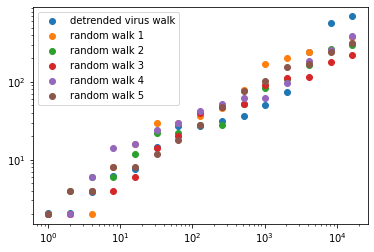

In [24]:
#Computing deviation for detrended virus walk:
dev1=deviation(detrended_virus_walk)#Assigns deviation(detrended_virus_walk) to the variable dev1.

#Computing deviation for random walks:
dev2=deviation(r1)#The random walks from question 2.6 are used here (for convinience). Each is assigned a variable
dev3=deviation(r2)#for accuracy and convinience.
dev4=deviation(r3)
dev5=deviation(r4)
dev6=deviation(r5)

#Scatter plot of the deviations:
plt.scatter(*zip(*dev1), label='detrended virus walk')#The inbuilt function zip and asterisks are used here to
plt.scatter(*zip(*dev2),label='random walk 1') #take the contents of the tuples as the x and y coordinates. Each graph is
plt.scatter(*zip(*dev3),label='random walk 2') #labelled.
plt.scatter(*zip(*dev4),label='random walk 3')
plt.scatter(*zip(*dev5),label='random walk 4')
plt.scatter(*zip(*dev6),label='random walk 5')
plt.yscale('log') #Produces logarithmic y axis.
plt.xscale('log')#Produces logarithmic x axis.
plt.legend() #Displays legend.
plt.show()#Displays the figure.

#Sources:
#https://stackoverflow.com/questions/17411940/matplotlib-scatter-plot-legend
#https://www.kite.com/python/answers/how-to-append-elements-to-a-list-while-iterating-over-the-list-in-python

---
**[3.6]** A power law function $f(z)=az^b$ appears as a straight line when plotted in logarithmic axes. This is so because taking logarithms at both sides of the power law function, we have
$\log(f(z)) = b\log(z) + \log(a)$, so if we perform a logarithmic transformation  $\tilde{Y}=\log(f(z))$ and $\tilde{X}=\log(z)$, in the new variables the power law function is a straight line $\tilde{Y} = b \tilde{X} + \log(a)$, with slope $b$.

Fit a power law function of the form $f(z)=az^b$ to the $scaling$ data for the *detrended_virus_walk* by making a linear fit to the logarithmically transformed data. Display the fitted curve together with the scatter plot of the *scaling* data.

Give estimates of $a$ and $b$. Investigate in Google and, in a markdown box, explain what $b$ is, and, according to its estimated value, briefly discuss what this tells us about the data, and in this case, about the virus.

---


The value of b is: 0.5802292433363196
,The value of a is: 1.6329551264477722


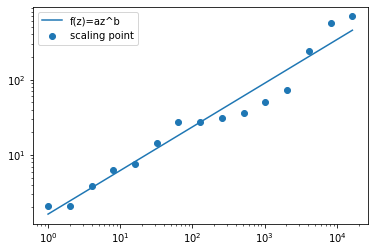

In [26]:
#I used a function to transform x and y to logx and logy, shown below.

def transformation(z):#Defines the function transformation, that takes a list of coordinates (tuples) as an input.
    transformedx=[]#Empty list to store the transformed x coordinates.
    transformedy=[]#Empty list to store the transformed y coordinates.
    new_coord=[]#Empty list to store both transformed coordinates as a tuple.
    for item in z:#For each coordinate in the list of coordinates,
        x=item[0]#the first value in the coordinate is assigned to x.
        y=item[1]#the second value in the coordinate is assigned to y.
        transformedx.append(np.log(x))# the  function computes logx for each element x and stores it in the list transformedx.
        transformedy.append(np.log(y))# the function computes logy for each element y and it is stored in the list transformedy.
    for item in list(zip(transformedx,transformedy)):
        new_coord.append(item)#Each coordinate is finally stored in the list new_coord.
    return new_coord #The transformed coordinates are displayed for each list of coordinates.


#Estimates for a and b. 
#log(a) is the intercept and b is the gradient of the power law function.
b_dev1=linear_fit(transformation(dev1))[0]
log_a=linear_fit(transformation(dev1))[1]
a_dev1=np.exp(log_a)

#b_dev1=linear_fit(transformation(dev1))[0]#The list of coordinates are taken as an input to linear _fit to produce values of 
#log_a=linear_fit(transformation(dev1))[1] #the gradient and the intercept of the least-squares fit for the transformed coordinates.
#a_dev1=np.exp(log_a) #Computes e^log(a) to get the gradient,a.

#Displaying the values of a and b:
print('The value of b is:',b_dev1)#Displays the value of b in f(z)=az^b.
print('The value of a is:',a_dev1)#Displays the value of a in f(z)=az^b.


#Computuing the x coordinates, and az^b:
xcoord=[i[0] for i in dev1] #The x coordinates of the deviation(detrended_virus_walk).
power_law=[np.exp(log_a)*i[0]**b_dev1 for i in dev1] #Computes y coordinates where y=az^b.


#Plotting the graph:
plt.yscale('log')#Produces logarithmic y axis.
plt.xscale('log')#Produces logarithmic x axis.
plt.plot(xcoord,power_law, label='f(z)=az^b') #Plots the x coordinates and power_law computed above.
plt.scatter(*zip(*dev1), label='scaling point') #Plots the scatter graph from the scaling data, as in the previous question(in the same graph).
plt.legend()#Displays the legend.
plt.show()#Displays the figure.


The gradient of our graph, b, is known as the exponent.The exponent allows for identification of coding regions in genetic sequences and hence is extremely useful for reasearchers working with lengthy DNA sequences. If the value obtained for the exponent is approximately the estimated value of 0.5, then there is a greater likelihood that the sub-region belongs to the coding part of the viral sequence. Alternatively, if the value obtained for the exponent is far greater than the estimated value, then there is a greater likelihood that the sub-region belongs to the non-coding part of the viral sequence.

Given that we obtained a value of 0.58 for the exponent, which is greater than the estimated value of 0.5, there is a greater likelihood the region we were analysing belongs to the non-coding region of the viral sequence.